# **ETTh1 Analysis**
---
Conducted independently of any model design to learn about the data and prepare modelling approach


---
# ADD  
---

  print(f"Training split mean: {training_split["OT"].mean()}") 

  print(f"Validation split mean: {validation_split["OT"].mean()}")
  
  print(f"Test split mean: {test_split["OT"].mean()}")


In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## **Import and Plot**
The imported DataFrame has a shape of $ \mathrm{data\_ETTh1} \isin \R^{Tx7} $

In [60]:
# Import full data set from original source
url =  "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv"

data_ETTh1 = pd.read_csv(url, sep = ",")
data_ETTh1.set_index('date', inplace=True)
data_ETTh1.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

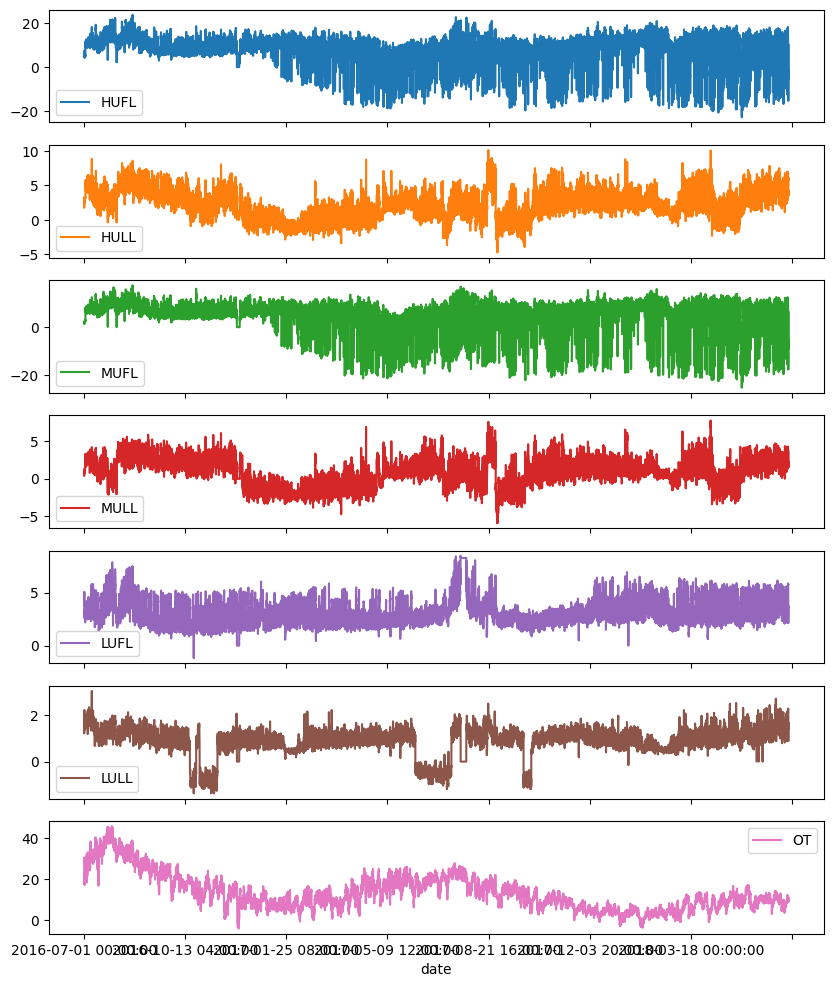

In [61]:
# Plot each column of the data set to visualize the time series data
data_ETTh1.plot(subplots=True, figsize=(10, 12))

---
## **Pre-Analysis Data Splitting & Truncating**
- *Any insights gained from the data set must only come from the training set, otherwise it risks data leakage (e.g. periodicities which only show later in the set etc.)*
- Using the recommended typical 12 - 4 - 4 split here, resulting in a total of 20 months of data
- The dataset contains almost 24 months, so the remaining c. 4 months get cut and are **unused** (=truncated)

In [ ]:
# Number of rows in the source ETTh1 data set
timesteps_source = data_ETTh1.shape[0]     # hours in the full length dataset (rows in the original data frame)
print("Timesteps in the source dataset: ", timesteps_source, "hours")

# Splitting into training, validation, and test sets
hours_per_month = 30 * 24           # hours

training_length   = 12 * hours_per_month         # 12 months
validation_length = 4 * hours_per_month          # 4 months
test_length       = 4 * hours_per_month          # 4 months   

# Create training, validation, and test sets
training_set_raw    = data_ETTh1.iloc[:training_length]
validation_set_raw  = data_ETTh1.iloc[training_length:(training_length + validation_length)]
test_set_raw        = data_ETTh1.iloc[(training_length + validation_length):(training_length + validation_length + test_length)]
discarded_set_raw   = data_ETTh1.iloc[(training_length + validation_length + test_length):]

timesteps = training_set_raw.shape[0] + validation_set_raw.shape[0] + test_set_raw.shape[0]

print("Timesteps in the truncated set: ", timesteps, "hours")
print("Timesteps in the training set: ", training_set_raw.shape[0], "hours")
print("Timesteps in the discarded set: ", discarded_set_raw.shape[0], "hours")

print("The training/validation/test split relative to the truncated set [%]: ", training_set_raw.shape[0]/timesteps*100, "/", validation_set_raw.shape[0]/timesteps*100, "/", test_set_raw.shape[0]/timesteps*100)

Timesteps in the source dataset:  17420 hours
Timesteps in the truncated set:  14400 hours
Timesteps in the training set:  8640 hours
Timesteps in the discarded set:  3020 hours
The training/validation/test split relative to the truncated set [%]:  60.0 / 20.0 / 20.0


---
## **Signal Cross-Correlation**
- The raw training set is much stronger (linearly) correlated than the full source data set --> risk of overtraining dependencies?

### **Full Length Source Data**
- relatively weak or barely existent linear correlations between the channels, much lower than for the raw training data

In [66]:
# Determine cross-correlation between the data columns
cross_corr = data_ETTh1.corr()

# Reduce the cross-correlation matrix to only include the upper triangle
cross_corr = cross_corr.where(np.triu(np.ones(cross_corr.shape), k=1).astype(bool))

# Round the cross-correlation values to 2 decimal places
cross_corr = cross_corr.round(2)

# Display the cross-correlation matrix
print("Cross-Correlation Matrix of Raw Training Data:")
print(cross_corr)


Cross-Correlation Matrix of Raw Training Data:
      HUFL  HULL  MUFL  MULL  LUFL  LULL    OT
HUFL   NaN  0.11  0.99  0.07  0.29  0.02  0.06
HULL   NaN   NaN  0.07  0.93  0.26  0.38  0.22
MUFL   NaN   NaN   NaN  0.05  0.18 -0.05  0.05
MULL   NaN   NaN   NaN   NaN  0.13  0.07  0.22
LUFL   NaN   NaN   NaN   NaN   NaN  0.33  0.12
LULL   NaN   NaN   NaN   NaN   NaN   NaN  0.07
OT     NaN   NaN   NaN   NaN   NaN   NaN   NaN


### **Raw Training Data**
- OT (oil temperature) is significantly linearly correlated to most other time series.
- Check again after trends and seasonalities have been removed by MSTL?

In [65]:
# Determine cross-correlation between the data columns
cross_corr = training_set_raw.corr()

# Reduce the cross-correlation matrix to only include the upper triangle
cross_corr = cross_corr.where(np.triu(np.ones(cross_corr.shape), k=1).astype(bool))

# Round the cross-correlation values to 2 decimal places
cross_corr = cross_corr.round(2)

# Display the cross-correlation matrix
print("Cross-Correlation Matrix of Raw Training Data:")
print(cross_corr)


Cross-Correlation Matrix of Raw Training Data:
      HUFL  HULL  MUFL  MULL  LUFL  LULL    OT
HUFL   NaN  0.23  0.98  0.15  0.40  0.11  0.20
HULL   NaN   NaN  0.20  0.93  0.23  0.30  0.60
MUFL   NaN   NaN   NaN  0.14  0.23  0.04  0.15
MULL   NaN   NaN   NaN   NaN  0.05 -0.04  0.52
LUFL   NaN   NaN   NaN   NaN   NaN  0.44  0.32
LULL   NaN   NaN   NaN   NaN   NaN   NaN  0.28
OT     NaN   NaN   NaN   NaN   NaN   NaN   NaN


---
## **Checking for Periodicities with FFT**
- All columns show clear periodicity every 24 hours, most also for 12h and some for even shorter periods
- There is no clearly observable periodicity around 168 h for OT or other datasets. It may looks like it in the plot, but the FFT didn't find it --> likely due to limited data in this range of periods due to overall dataset length --> do not add manually, the model can only use what it would find itself
- The results slightly shift between set length, suggesting temporal behavior is dynamic

### **Raw Training Set**

/tmp/ipykernel_26898/2217160172.py:7: RuntimeWarning: divide by zero encountered in divide
  periods_all = 1 / frequencies_all   # Assuming the data is hourly, convert to daily frequencies


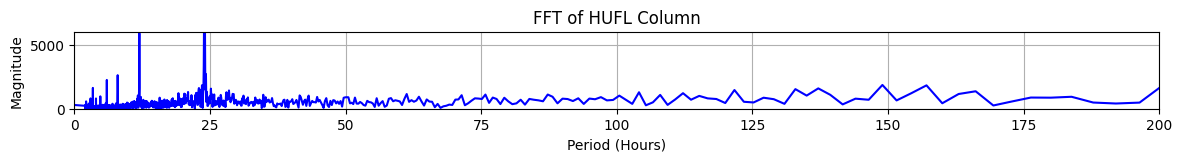

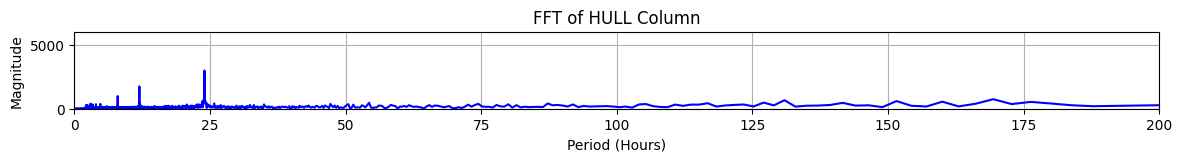

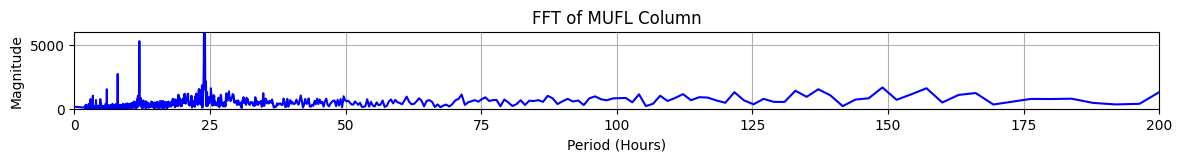

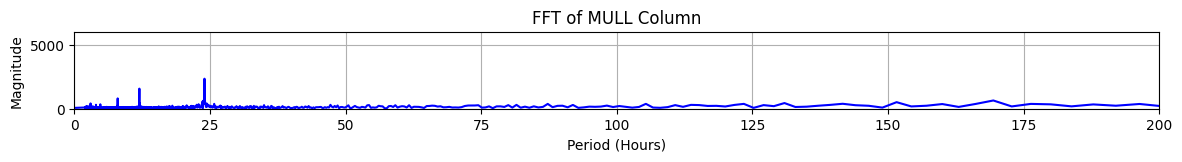

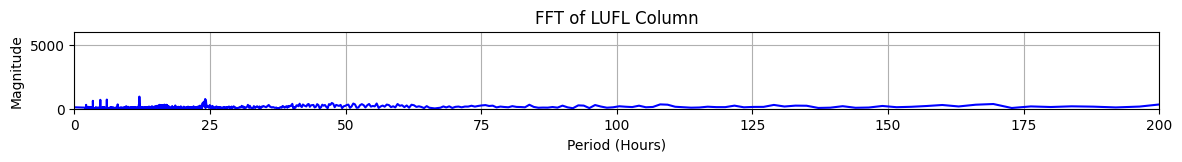

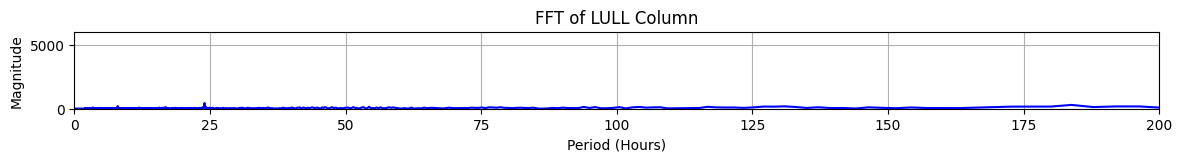

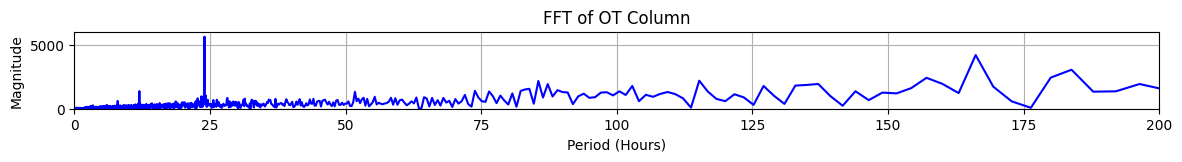

In [73]:
# Performing FFT of the whole ETTh1 dataset to analyze the frequency components of all columns
# Perform Fast Fourier Transform (FFT) on the entire dataset
fft_values_all = np.fft.fft(training_set_raw, axis=0)

frequencies_all = np.fft.fftfreq(len(fft_values_all), d=1)  # d=1 assumes unit time interval

periods_all = 1 / frequencies_all   # Assuming the data is hourly, convert to daily frequencies

# Plot the magnitude of the FFT values against the frequencies

for column in training_set_raw.columns:
    plt.figure(figsize=(14, 1))
    plt.plot(periods_all, np.abs(fft_values_all[:, training_set_raw.columns.get_loc(column)]), color='blue')
    plt.title(f'FFT of {column} Column')
    plt.xlabel('Period (Hours)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 200)  # Limit x-axis to focus on low frequencies
    plt.ylim(0, 6000)  # Limit y-axis for better visibility
    plt.grid()
    plt.show()

### **Full Length Source Data**

/tmp/ipykernel_26898/2238511082.py:7: RuntimeWarning: divide by zero encountered in divide
  periods_all = 1 / frequencies_all   # Assuming the data is hourly, convert to daily frequencies


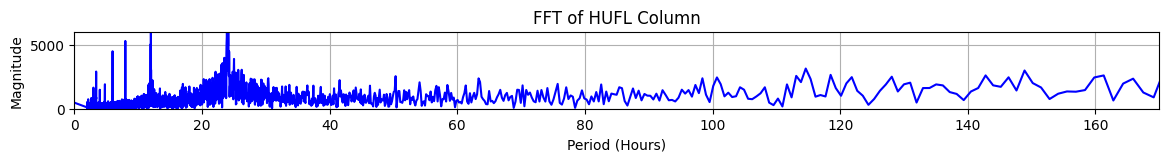

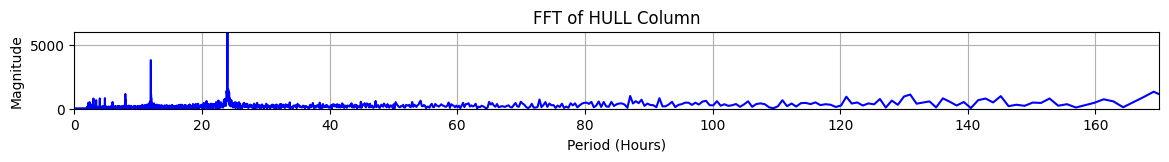

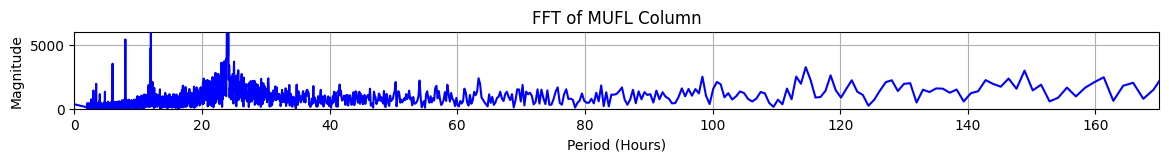

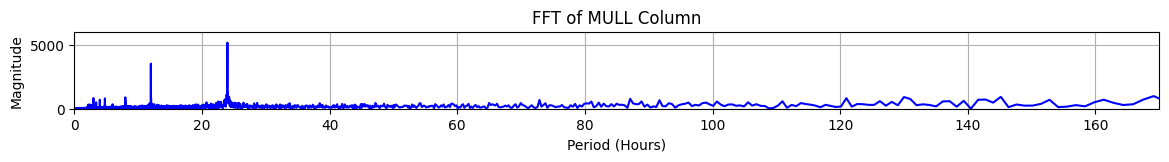

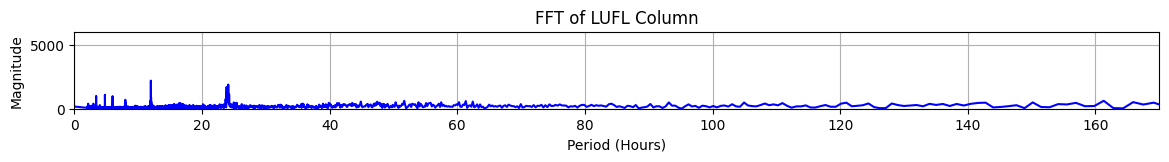

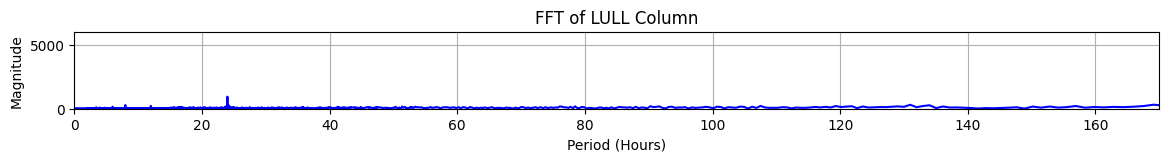

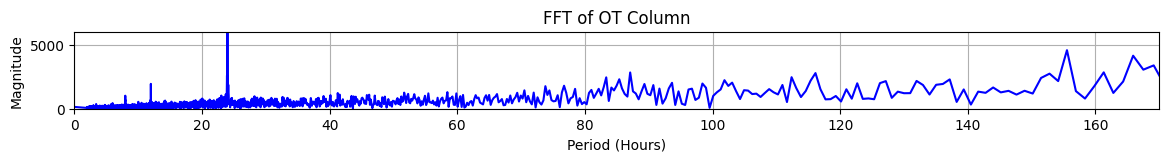

In [72]:
# Performing FFT of the whole ETTh1 dataset to analyze the frequency components of all columns
# Perform Fast Fourier Transform (FFT) on the entire dataset
fft_values_all = np.fft.fft(data_ETTh1, axis=0)

frequencies_all = np.fft.fftfreq(len(fft_values_all), d=1)  # d=1 assumes unit time interval

periods_all = 1 / frequencies_all   # Assuming the data is hourly, convert to daily frequencies

# Plot the magnitude of the FFT values against the frequencies

for column in data_ETTh1.columns:
    plt.figure(figsize=(14, 1))
    plt.plot(periods_all, np.abs(fft_values_all[:, data_ETTh1.columns.get_loc(column)]), color='blue')
    plt.title(f'FFT of {column} Column')
    plt.xlabel('Period (Hours)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 170)  # Limit x-axis to focus on low frequencies
    plt.ylim(0, 6000)  # Limit y-axis for better visibility
    plt.grid()
    plt.show()

---
## **Summary**
- Overall, the signal seems to have significant dynamics in its temporal behavior
- (Linear) correlations get weaker the longer the analyzed set is

### Established Approaches
- Seems like DLinear and other super simple strategies avoid overfitting between the channels
- Frequency-space-based approaches like FITS are much smaller and equally performant, sometimes even better
- State-of-the-art models like Mamba and S4 should outperform because they avoid all cut-offs or hardcoded measures to improve long-term behavior sensitivity (like in FITS)

### Project Approach
- Go with a very simple multivariate DLinear for univariate OT forecasting first
- Compare to a SOTA model like Mamba, S4, or xLSTM (tbd)